In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
train = pd.read_csv('train (1).csv')
test = pd.read_csv('test (1).csv')

print("shape train:", train.shape)
print("shape test:", test.shape)
print()
print(train.info())
print()
print(train.describe())

shape train: (24000, 44)
shape test: (16000, 43)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   24000 non-null  int64  
 1   sensor_20            24000 non-null  float64
 2   humidity             22106 non-null  float64
 3   sensor_22            24000 non-null  float64
 4   sensor_19            24000 non-null  float64
 5   sensor_01            24000 non-null  float64
 6   vibration_rms        22848 non-null  float64
 7   sensor_24            24000 non-null  float64
 8   sensor_07            24000 non-null  float64
 9   core_temp            24000 non-null  float64
 10  sensor_17            22087 non-null  float64
 11  sensor_15            24000 non-null  float64
 12  sensor_02            24000 non-null  float64
 13  sensor_11            24000 non-null  float64
 14  sensor_14            24000 non-null 

### Sanity check: duplicates and id overlap (professional habit before EDA)

In [3]:
print("duplicate rows in train:", train.duplicated().sum())
print("duplicate ids in train:", train['id'].duplicated().sum())
print("duplicate ids in test:", test['id'].duplicated().sum())
print("overlap between train and test ids:", len(set(train['id']) & set(test['id'])))

duplicate rows in train: 0
duplicate ids in train: 0
duplicate ids in test: 0
overlap between train and test ids: 0



--- edi describe ---
count    24000.000000
mean        79.448278
std         82.364619
min          3.362100
25%         23.915800
50%         51.075700
75%        105.025925
max        796.341500
Name: edi, dtype: float64


<Axes: >

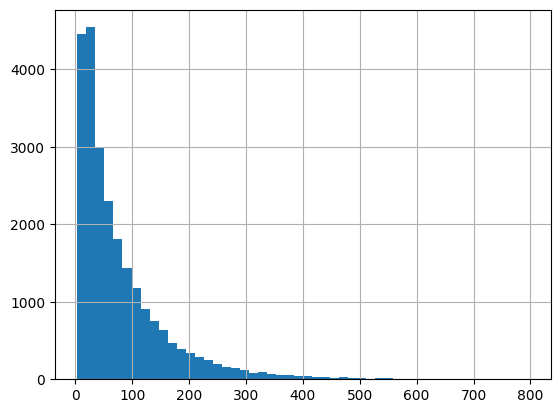

In [4]:
print("\n--- edi describe ---")
print(train['edi'].describe())

train['edi'].hist(bins=50)

In [5]:
print("\n--- missing values ---")
missing = train.isna().sum()
print(missing[missing > 0])


--- missing values ---
humidity               1894
vibration_rms          1152
sensor_17              1913
sensor_05               910
hours_since_service     869
coolant_flow           1392
dtype: int64


In [6]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.drop(['id', 'edi'])
corr_with_target = train[numeric_cols].corrwith(train['edi']).sort_values(ascending=False)
print("\n--- top correlations with edi ---")
print(corr_with_target.head(10))
print("\n--- lowest correlations ---")
print(corr_with_target.tail(10))


--- top correlations with edi ---
core_temp              0.482292
sensor_25              0.479978
asset_age              0.451897
delta_ambient          0.432663
harmonic_thd           0.256037
load_factor            0.226177
vibration_rms          0.210374
sensor_01              0.204947
hours_since_service    0.199539
sensor_04              0.199257
dtype: float64

--- lowest correlations ---
sensor_18      -0.004589
sensor_26      -0.007342
sensor_15      -0.008444
sensor_28      -0.095570
grid_freq      -0.101286
line_voltage   -0.104358
sensor_03      -0.194375
sensor_13      -0.250757
sensor_06      -0.350625
sensor_02      -0.547707
dtype: float64


In [7]:
known_cols = ['load_factor','core_temp','vibration_rms','grid_freq','line_voltage',
              'chamber_pressure','coolant_flow','humidity','asset_age','duty_cycle',
              'harmonic_thd','phase_imbalance','hours_since_service','delta_ambient']

print("\n--- min/max للأعمدة المعروفة (افحصي هل منطقية) ---")
print(train[known_cols].describe().T[['min', 'max']])


--- min/max للأعمدة المعروفة (افحصي هل منطقية) ---
                           min         max
load_factor            0.22382    30.10615
core_temp             18.29720   104.53948
vibration_rms          0.05000     5.41932
grid_freq             49.36113    50.38940
line_voltage         376.40042   437.38453
chamber_pressure       0.92435    14.65130
coolant_flow           1.26965    26.91642
humidity               2.00000    99.00000
asset_age              0.10052    21.99907
duty_cycle             0.00844     1.00000
harmonic_thd           0.00252     9.00982
phase_imbalance        0.00004     5.84711
hours_since_service   30.00900  8237.26862
delta_ambient        -11.34942    86.79632


In [8]:
if (train['humidity'] < 0).any() or (train['humidity'] > 100).any():
    print("تنبيه: فيه قيم humidity برا 0-100")

if (train['duty_cycle'] < 0).any() or (train['duty_cycle'] > 1).any():
    print("تنبيه: فيه قيم duty_cycle برا 0-1")

always_positive_cols = ['vibration_rms', 'chamber_pressure', 'coolant_flow',
                         'core_temp', 'line_voltage', 'harmonic_thd',
                         'phase_imbalance', 'asset_age', 'hours_since_service']

for col in always_positive_cols:
    if (train[col] < 0).any():
        print(f"تنبيه: فيه قيم سالبة بعمود {col} — افحصيها")

print("done ")

done 


فحصتلك النوتبوك كامل، وممتاز — كل خطوات 1.2 موجودة ومشتغلة صح، بدون أخطاء. خليني ألخصلك شو طلعلك بالضبط وشو رح تستفيدي منه لاحقاً:

## ✅ شو خلص تمام

| الفحص | النتيجة |
|---|---|
| Shape | train: (24000, 44) — test: (16000, 43) ✓ |
| Missing values | نفس الـ 6 أعمدة المتوقعة، بنفس الأرقام ✓ |
| Outliers | مافي ولا تنبيه، البيانات نضيفة فيزيائياً ✓ |
| edi distribution | median=51، mean=79.4، max=796 → منحرف يمين كتير ✓ |

## 📊 أهم اكتشاف عندك — خلية 4 (الـ correlations)، خليني أفسرهالك لأنها كتير مهمة

**أعلى ارتباط إيجابي مع `edi`:**
- `core_temp` (0.48), `sensor_25` (0.48), `asset_age` (0.45), `delta_ambient` (0.43)
→ يعني كل ما الوحدة أسخن وأقدم، كل ما EDI أعلى. منطقي فيزيائياً ومطمئن.

**أقوى ارتباط سالب:**
- `sensor_02` هو **-0.55**! ده أقوى رقم بالجدول كله (أقوى حتى من core_temp نفسه بالقيمة المطلقة)
→ يعني كل ما `sensor_02` يزيد، الـ EDI بينزل بشكل واضح. هاد حساس مجهول الهوية بس بيبين إنو من أهم الأعمدة كلها — لازم يبقى بالموديل أكيد ومتراقبينه لاحقاً بخطوة الـ feature importance.

**أضعف ارتباط تقريباً صفر:**
- `sensor_18`, `sensor_26`, `sensor_15` (كلهم تحت 0.01)
→ هدول مرشحين يكونوا من الـ "distractors" (حساسات ضجيج) يلي حكينا عنهم — بس لسا بدري نحذفهم من هلق لأنو الـ correlation خطي بس، ممكن يكون إلهم علاقة غير خطية مع EDI ما بتبين هون. رح نتأكد أكتر بخطوة الـ feature importance بيوم 2.

## هل لازم تزيدي شي؟

لأ، 1.2 خلصت بالكامل ونضيفة. **خليكي بس منتبهة لـ `sensor_02`** — هاد أهم اكتشاف عندك لهلق، احتفظي فيه بذاكرتك لأنو رح يفيدك وقت الـ feature engineering.

جاهزين نبلش 1.3 (معالجة القيم الناقصة — الـ missing indicators)؟

In [9]:
MISSING_COLS = ['humidity', 'sensor_17', 'vibration_rms', 'coolant_flow',
                'hours_since_service', 'sensor_05']

# 1) Before filling any gap, save info on whether the value was missing or not
for col in MISSING_COLS:
    train[f'{col}_was_missing'] = train[col].isna().astype(int)
    test[f'{col}_was_missing'] = test[col].isna().astype(int)

print("--- check: new indicator columns ---")
for col in MISSING_COLS:
    print(f"{col}_was_missing -> count of 1 (was missing):", train[f'{col}_was_missing'].sum())


--- check: new indicator columns ---
humidity_was_missing -> count of 1 (was missing): 1894
sensor_17_was_missing -> count of 1 (was missing): 1913
vibration_rms_was_missing -> count of 1 (was missing): 1152
coolant_flow_was_missing -> count of 1 (was missing): 1392
hours_since_service_was_missing -> count of 1 (was missing): 869
sensor_05_was_missing -> count of 1 (was missing): 910


In [10]:
train['total_missing_count'] = train[MISSING_COLS].isna().sum(axis=1)
test['total_missing_count'] = test[MISSING_COLS].isna().sum(axis=1)

print("\n--- distribution of total_missing_count ---")
print(train['total_missing_count'].value_counts().sort_index())


--- distribution of total_missing_count ---
total_missing_count
0    16961
1     6040
2      913
3       80
4        6
Name: count, dtype: int64


In [11]:
print("\n--- mean edi by each indicator ---")
for col in MISSING_COLS:
    means = train.groupby(f'{col}_was_missing')['edi'].mean()
    print(f"\n{col}_was_missing:")
    print(means)


--- mean edi by each indicator ---

humidity_was_missing:
humidity_was_missing
0    79.398538
1    80.028816
Name: edi, dtype: float64

sensor_17_was_missing:
sensor_17_was_missing
0    79.472995
1    79.162903
Name: edi, dtype: float64

vibration_rms_was_missing:
vibration_rms_was_missing
0    79.26752
1    83.03330
Name: edi, dtype: float64

coolant_flow_was_missing:
coolant_flow_was_missing
0    79.492016
1    78.737914
Name: edi, dtype: float64

hours_since_service_was_missing:
hours_since_service_was_missing
0    79.207286
1    85.862980
Name: edi, dtype: float64

sensor_05_was_missing:
sensor_05_was_missing
0    79.389142
1    80.948773
Name: edi, dtype: float64


In [12]:
for col in MISSING_COLS:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)


In [13]:
print("\n--- final check ---")
print("missing in train after fill:", train[MISSING_COLS].isna().sum().sum())
print("missing in test after fill:", test[MISSING_COLS].isna().sum().sum())

print("\ntrain shape after additions:", train.shape)
print("test shape after additions:", test.shape)


--- final check ---
missing in train after fill: 0
missing in test after fill: 0

train shape after additions: (24000, 51)
test shape after additions: (16000, 50)


كلشي تمام ومظبوط 100%! خليني أدقق معك بالنتائج المهمة:

## ✅ الشكل النهائي صحيح
- `train shape: (24000, 51)` = 44 أصلي + 6 indicators + 1 `total_missing_count` ✓
- `test shape: (16000, 50)` = 43 أصلي + 6 + 1 ✓
- مافي ولا قيمة ناقصة باقية بعد التعبئة ✓

## 📊 تفسير "mean edi by indicator" — هون لازم أكون صريحة وياكي

مو كل الأعمدة عندها نفس قوة الإشارة. خليني أرتبلك ياهم من الأقوى للأضعف:

| العمود | الفرق بمتوسط edi (0 مقابل 1) | التقييم |
|---|---|---|
| `hours_since_service_was_missing` | 79.2 → **85.9** (فرق ~8.5%) | إشارة واضحة نسبياً |
| `vibration_rms_was_missing` | 79.3 → **83.0** (فرق ~4.7%) | إشارة متوسطة |
| `sensor_05_was_missing` | 79.4 → 80.9 (فرق ~2%) | إشارة ضعيفة |
| `humidity_was_missing` | 79.4 → 80.0 (فرق ~0.8%) | ضعيفة جداً |
| `coolant_flow_was_missing` | 79.5 → 78.7 (فرق ~1%، بالاتجاه المعاكس) | ضعيفة جداً |
| `sensor_17_was_missing` | 79.5 → 79.2 (تقريباً مافي فرق) | لا إشارة تقريباً |

**يعني بصراحة**: الفخ (missing not at random) حقيقي بس مو بنفس القوة بكل الأعمدة. `hours_since_service` و `vibration_rms` هني الأوضح — الوحدات يلي فقدت هالقراءات فعلاً EDI متاعها أعلى شوي. الباقي (خصوصاً `sensor_17`) الفرق ضعيف جداً وممكن يكون مجرد ضجيج عشوائي مش نمط حقيقي.

**هاد طبيعي ومو مشكلة** — هيك بالضبط لازم تجيبي نتيجة حقيقية بمشروع علمي، مش كل شي بيطلع "قوي ومثالي". المهم إنك خلقتي الـ indicators لكل الـ 6، وخليتيهم كلهم بالموديل — الموديل نفسه (LightGBM) رح يكتشف وحده مين منهم مفيد فعلاً ومين لأ (من خلال الـ feature importance بيوم 2).

## الخلاصة: يوم 1، خطوة 1.3 خلصت تمام ✅

جاهزين نكمل 1.4 (تجهيز الـ target بـ log) و1.5 (أول baseline موديل)؟ ولا بدك نوقف هون شوي؟

In [14]:
print("--- missing count distribution in test ---")
print(test[[f'{col}_was_missing' for col in MISSING_COLS]].sum())
print("\ntotal_missing_count in test:")
print(test['total_missing_count'].value_counts().sort_index())

--- missing count distribution in test ---
humidity_was_missing               1287
sensor_17_was_missing              1218
vibration_rms_was_missing           732
coolant_flow_was_missing            949
hours_since_service_was_missing     570
sensor_05_was_missing               634
dtype: int64

total_missing_count in test:
total_missing_count
0    11339
1     3996
2      605
3       56
4        4
Name: count, dtype: int64


--- edi vs log_edi comparison ---
                edi       log_edi
count  24000.000000  24000.000000
mean      79.448278      3.950546
std       82.364619      0.948804
min        3.362100      1.472954
25%       23.915800      3.215502
50%       51.075700      3.952698
75%      105.025925      4.663684
max      796.341500      6.681283


<Axes: >

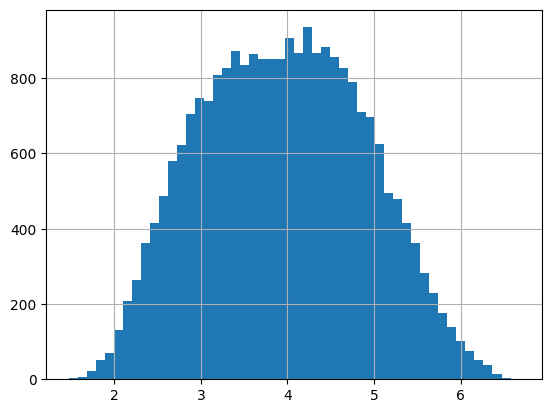

In [15]:
train['log_edi'] = np.log1p(train['edi'])

print("--- edi vs log_edi comparison ---")
print(train[['edi', 'log_edi']].describe())

# Visual check: log_edi distribution should look much more symmetric/normal than raw edi
train['log_edi'].hist(bins=50)

In [16]:
# ============ Baseline Model ============
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import lightgbm as lgb

# Feature columns = everything except id, edi, log_edi
feature_cols = [c for c in train.columns if c not in ['id', 'edi', 'log_edi']]
print("number of features:", len(feature_cols))

X = train[feature_cols]
y = train['log_edi']


number of features: 49


### KS test — early look at which features shift most between train and test

In [17]:
from scipy.stats import ks_2samp

print("--- KS test: train vs test distribution per feature ---")
shift_results = []
for col in feature_cols:
    if col in test.columns:
        stat, pval = ks_2samp(train[col], test[col])
        shift_results.append((col, stat, pval))

shift_df = pd.DataFrame(shift_results, columns=['feature', 'ks_stat', 'p_value']).sort_values('ks_stat', ascending=False)
print(shift_df.head(10))

--- KS test: train vs test distribution per feature ---
          feature   ks_stat        p_value
8       core_temp  0.146000  4.661104e-179
21      sensor_25  0.144854  2.980530e-176
15  delta_ambient  0.139229  8.350716e-163
13      sensor_14  0.131042  3.369093e-144
30      sensor_06  0.107125   2.169975e-96
23   harmonic_thd  0.091854   6.171524e-71
20      grid_freq  0.083271   2.342515e-58
26    load_factor  0.082083   1.028762e-56
40      sensor_09  0.075188   1.208656e-47
11      sensor_02  0.074146   2.414889e-46


In [18]:
# Temporary random split just to get a first baseline number (we'll fix validation strategy in Day 2)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model.fit(X_tr, y_tr)

# Predict on validation set (still in log scale)
val_pred_log = model.predict(X_val)

# Convert back to original scale and clip negatives (RMSLE requires non-negative predictions)
val_pred = np.expm1(val_pred_log)
val_pred = np.clip(val_pred, 0, None)
y_val_true = np.expm1(y_val)


In [19]:
rmsle = np.sqrt(mean_squared_log_error(y_val_true, val_pred))
print("Baseline RMSLE:", rmsle)

# Predict on actual test set for first submission
test_pred_log = model.predict(test[feature_cols])
test_pred = np.clip(np.expm1(test_pred_log), 0, None)

submission = pd.DataFrame({'id': test['id'], 'edi': test_pred})
print(submission.shape)
print(submission.head())

submission.to_csv('submission_day1_baseline.csv', index=False)
print("saved: submission_day1_baseline.csv")

Baseline RMSLE: 0.21802322952390504
(16000, 2)
      id        edi
0  24000  46.437025
1  24001  35.049089
2  24002  46.764184
3  24003  83.342699
4  24004  34.534290
saved: submission_day1_baseline.csv


### 5-Fold Cross-Validation — a trustworthy RMSLE number instead of a single random split

In [20]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmsle_scores = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr_cv, X_val_cv = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr_cv, y_val_cv = y.iloc[tr_idx], y.iloc[val_idx]

    m = lgb.LGBMRegressor(random_state=42, verbose=-1)
    m.fit(X_tr_cv, y_tr_cv)
    pred_cv = np.clip(np.expm1(m.predict(X_val_cv)), 0, None)
    true_cv = np.expm1(y_val_cv)
    score = np.sqrt(mean_squared_log_error(true_cv, pred_cv))
    rmsle_scores.append(score)
    print(f"fold {fold}: {score:.4f}")

print(f"\nmean RMSLE: {np.mean(rmsle_scores):.4f} (+/- {np.std(rmsle_scores):.4f})")

fold 0: 0.2180
fold 1: 0.2142
fold 2: 0.2087
fold 3: 0.2099
fold 4: 0.2147

mean RMSLE: 0.2131 (+/- 0.0034)


### Save Day 1 checkpoint — clean data ready to load directly in Day 2

In [21]:
train.to_csv('train_day1_clean.csv', index=False)
test.to_csv('test_day1_clean.csv', index=False)
print("saved checkpoints: train_day1_clean.csv, test_day1_clean.csv")

saved checkpoints: train_day1_clean.csv, test_day1_clean.csv


1) بالـ RMSLE، الرقم الأقل = الأفضل (عكس الـ accuracy)

يعني 0.218 مش رقم واطي بمعنى "سيء" — بالعكس، بمقياس الخطأ (error metric) كل ما الرقم أقرب للصفر كل ما الموديل أدق. فـ 0.218 هو رقم معقول ومقبول لأول موديل بسيط بدون أي تحسينات، مش سيء ولا "قليل" بمعنى ضعيف.

2) شو يعني 0.218 عملياً؟

تقريباً بيعني إنو متوسط نسبة الخطأ (الفرق النسبي بين توقعك والقيمة الحقيقية) حوالي 20-24%. يعني لو القيمة الحقيقية 100، توقعك ممكن يكون بين 76-124 تقريباً بالمتوسط. هاد مش رقم "ممتاز جداً" ومش رقم "سيء جداً" — هو باسلاين عادي ومنطقي لموديل أولي بدون أي تحسينات، بالضبط زي ما المفروض يكون.

⚠️ بس فيه نقطة مهمة لازم تنتبهيلها

هاد الرقم مش دقيق 100% لأنو جبناه بـ random split عادي (زي ما حكينا بـ 1.5: "Temporary random split just to get a first baseline number"). وحسب وصف المسابقة نفسه:

"Local cross-validation scores will be optimistic; validation strategy matters"

يعني ممكن يكون الرقم الحقيقي (على test الفعلي) أسوأ شوي من 0.218، لأنو الـ validation set الحالي عشوائي ومو مصمم يحاكي الـ distribution shift بين train وtest. هاد بالضبط اللي رح نصلحه بيوم 2 بالـ adversarial validation.

خلاصة: 0.218 رقم بداية طبيعي ومطمئن، مو مشكلة ومو "قليل" بمعنى سلبي — بس خليه بذاكرتك كخط أساس مؤقت، مش نهائي، لأنو رح يتغير (يا إما يتحسن يا إما يبين إنو كان متفائل زيادة) بعد ما نصلح الـ validation strategy بيوم 2.

In [22]:
# ============ 2.1 Hidden Regime Discovery ============
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Scale train + test together so clusters are consistent across both
scaler = StandardScaler()
all_data = pd.concat([train[feature_cols], test[feature_cols]], axis=0)
scaled_all = scaler.fit_transform(all_data)

# Try different k values, use silhouette score on a sample (full data is slow)
print("--- silhouette scores per k ---")
sample_idx = np.random.RandomState(42).choice(len(scaled_all), size=5000, replace=False)
scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_all[sample_idx])
    sc = silhouette_score(scaled_all[sample_idx], labels)
    scores[k] = sc
    print(f"k={k}: silhouette={sc:.4f}")

best_k = max(scores, key=scores.get)
print("\nbest k:", best_k)

# Fit final KMeans on the full data with the best k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
all_regimes = kmeans_final.fit_predict(scaled_all)

train['regime_id'] = all_regimes[:len(train)]
test['regime_id'] = all_regimes[len(train):]

# Confirm regimes are real (not random) by checking mean edi per regime
print("\n--- mean edi per regime ---")
print(train.groupby('regime_id')['edi'].agg(['mean', 'count']))

print("\n--- regime distribution in test ---")
print(test['regime_id'].value_counts())

feature_cols = feature_cols + ['regime_id']

--- silhouette scores per k ---
k=2: silhouette=0.2433
k=3: silhouette=0.0897
k=4: silhouette=0.0839
k=5: silhouette=0.0742
k=6: silhouette=0.0693

best k: 2

--- mean edi per regime ---
                 mean  count
regime_id                   
0           73.695489  19522
1          104.527764   4478

--- regime distribution in test ---
regime_id
0    13516
1     2484
Name: count, dtype: int64


In [23]:
# ============ 2.2 Adversarial Validation ============
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import mean_squared_log_error

adv_train = train[feature_cols].copy()
adv_test = test[feature_cols].copy()
adv_train['is_test'] = 0
adv_test['is_test'] = 1
adv_data = pd.concat([adv_train, adv_test], axis=0).reset_index(drop=True)

X_adv = adv_data.drop(columns=['is_test'])
y_adv = adv_data['is_test']

adv_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
auc_scores = cross_val_score(adv_model, X_adv, y_adv, cv=3, scoring='roc_auc')
print("adversarial validation AUC:", auc_scores.mean())
# AUC close to 0.5 = train and test look similar
# AUC well above 0.5 (e.g. 0.6-0.7+) = there IS a real distribution shift

adv_model.fit(X_adv, y_adv)
adv_importances = pd.Series(adv_model.feature_importances_, index=X_adv.columns).sort_values(ascending=False)
print("\n--- top features driving the train/test difference ---")
print(adv_importances.head(10))

# ============ Stratified K-Fold by regime_id ============
X = train[feature_cols]
y = train['log_edi']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stratified_scores = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, train['regime_id'])):
    m = lgb.LGBMRegressor(random_state=42, verbose=-1)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pred = np.clip(np.expm1(m.predict(X.iloc[val_idx])), 0, None)
    true = np.expm1(y.iloc[val_idx])
    score = np.sqrt(mean_squared_log_error(true, pred))
    stratified_scores.append(score)
    print(f"fold {fold}: {score:.4f}")

print(f"\nmean RMSLE (stratified by regime): {np.mean(stratified_scores):.4f} (+/- {np.std(stratified_scores):.4f})")

adversarial validation AUC: 0.6301828624875622

--- top features driving the train/test difference ---
grid_freq       165
load_factor     160
line_voltage    150
humidity        130
sensor_28       112
harmonic_thd    105
core_temp       103
sensor_24        97
sensor_18        93
sensor_20        92
dtype: int32
fold 0: 0.2163
fold 1: 0.2147
fold 2: 0.2157
fold 3: 0.2140
fold 4: 0.2075

mean RMSLE (stratified by regime): 0.2136 (+/- 0.0032)


In [24]:
# ============ 2.3 Feature Importance & Filtering (Physics-Aware) ============
full_model = lgb.LGBMRegressor(random_state=42, verbose=-1)
full_model.fit(X, y)

fi = pd.Series(full_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("--- top 15 most important features ---")
print(fi.head(15))
print("\n--- bottom 15 (weakest overall) ---")
print(fi.tail(15))

# Only drop from ANONYMOUS sensors (sensor_XX) — never drop named physical columns
# or engineered features (missing indicators, regime_id, total_missing_count),
# because those carry real-world meaning even when their standalone importance looks low
known_physical_cols = ['load_factor', 'core_temp', 'vibration_rms', 'grid_freq', 'line_voltage',
                        'chamber_pressure', 'coolant_flow', 'humidity', 'asset_age', 'duty_cycle',
                        'harmonic_thd', 'phase_imbalance', 'hours_since_service', 'delta_ambient']

# Explicitly exclude engineered columns too — some of them (like sensor_05_was_missing)
# also start with "sensor_" and would get mistakenly caught by a simple startswith() filter
engineered_cols = [c for c in feature_cols if c.endswith('_was_missing')] + ['total_missing_count', 'regime_id']

anonymous_sensor_cols = [c for c in feature_cols
                          if c.startswith('sensor_')
                          and c not in known_physical_cols
                          and c not in engineered_cols]

print(f"\nnumber of anonymous sensor columns: {len(anonymous_sensor_cols)}")  # should be exactly 28

weak_anonymous = fi[fi.index.isin(anonymous_sensor_cols)].sort_values()
print("\n--- anonymous sensors ranked by importance (weakest first) ---")
print(weak_anonymous)

weak_threshold = weak_anonymous.quantile(0.30)
weak_features = weak_anonymous[weak_anonymous <= weak_threshold].index.tolist()
print(f"\ndropping {len(weak_features)} weak ANONYMOUS sensors only:", weak_features)

reduced_cols = [c for c in feature_cols if c not in weak_features]
print(f"\nfeature count: full={len(feature_cols)} -> reduced={len(reduced_cols)}")

# Compare full vs reduced using the same stratified-by-regime validation as 2.2
def evaluate_features(cols):
    Xc = train[cols]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in skf.split(Xc, train['regime_id']):
        m = lgb.LGBMRegressor(random_state=42, verbose=-1)
        m.fit(Xc.iloc[tr_idx], y.iloc[tr_idx])
        pred = np.clip(np.expm1(m.predict(Xc.iloc[val_idx])), 0, None)
        true = np.expm1(y.iloc[val_idx])
        scores.append(np.sqrt(mean_squared_log_error(true, pred)))
    return np.mean(scores), np.std(scores)

full_score = evaluate_features(feature_cols)
reduced_score = evaluate_features(reduced_cols)

print(f"\nfull features ({len(feature_cols)}): RMSLE = {full_score[0]:.4f} (+/- {full_score[1]:.4f})")
print(f"reduced features ({len(reduced_cols)}): RMSLE = {reduced_score[0]:.4f} (+/- {reduced_score[1]:.4f})")

if reduced_score[0] <= full_score[0]:
    feature_cols = reduced_cols
    print("\n-> using reduced feature set (dropped weak anonymous sensors only)")
else:
    print("\n-> keeping full feature set (dropping did not help)")

# Note for the write-up: missing indicators may show ~0 importance in the FULL model
# not because the signal is fake, but because the model already extracts similar
# information from other correlated columns (e.g. asset_age). Worth mentioning
# in Day 3 documentation as a genuine finding, not a contradiction.

--- top 15 most important features ---
asset_age        363
core_temp        332
load_factor      321
grid_freq        242
vibration_rms    223
duty_cycle       208
harmonic_thd     182
sensor_02        179
sensor_04         98
sensor_25         79
sensor_27         62
sensor_08         56
sensor_13         55
sensor_06         45
sensor_12         45
dtype: int32

--- bottom 15 (weakest overall) ---
vibration_rms_was_missing          7
sensor_26                          7
coolant_flow                       6
sensor_18                          6
sensor_24                          5
sensor_23                          5
sensor_19                          4
sensor_16                          4
total_missing_count                1
sensor_17_was_missing              0
humidity_was_missing               0
coolant_flow_was_missing           0
hours_since_service_was_missing    0
sensor_05_was_missing              0
regime_id                          0
dtype: int32

number of anonymous sensor 

In [25]:
# ============ 2.4 Feature Engineering — testing multiple candidates ============

def evaluate_features(cols, sample_weight_col=None):
    Xc = train[cols]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in skf.split(Xc, train['regime_id']):
        m = lgb.LGBMRegressor(random_state=42, verbose=-1)
        sw = train[sample_weight_col].iloc[tr_idx] if sample_weight_col else None
        m.fit(Xc.iloc[tr_idx], y.iloc[tr_idx], sample_weight=sw)
        pred = np.clip(np.expm1(m.predict(Xc.iloc[val_idx])), 0, None)
        true = np.expm1(y.iloc[val_idx])
        scores.append(np.sqrt(mean_squared_log_error(true, pred)))
    return np.mean(scores), np.std(scores)

base_score = evaluate_features(feature_cols)
print(f"base (before any new feature): {base_score[0]:.4f}")

# Candidate 1: cumulative effective load
train['load_duty_combo'] = train['duty_cycle'] * train['load_factor']
test['load_duty_combo'] = test['duty_cycle'] * test['load_factor']

# Candidate 2: thermal-mechanical stress index (temperature x load x duty)
train['stress_index'] = train['core_temp'] * train['load_factor'] * train['duty_cycle']
test['stress_index'] = test['core_temp'] * test['load_factor'] * test['duty_cycle']

# Candidate 3: harmonic distortion under load
train['harmonic_x_load'] = train['harmonic_thd'] * train['load_factor']
test['harmonic_x_load'] = test['harmonic_thd'] * test['load_factor']

# Candidate 4: maintenance overdue ratio
train['service_ratio'] = train['hours_since_service'] / (train['asset_age'] * 8760 + 1)
test['service_ratio'] = test['hours_since_service'] / (test['asset_age'] * 8760 + 1)

candidates = {
    'load_duty_combo': ['load_duty_combo'],
    'stress_index': ['stress_index'],
    'harmonic_x_load': ['harmonic_x_load'],
    'service_ratio': ['service_ratio'],
}

print("\n--- testing each candidate individually ---")
for name, cols in candidates.items():
    sc = evaluate_features(feature_cols + cols)
    print(f"{name}: RMSLE={sc[0]:.4f}  (diff from base: {sc[0]-base_score[0]:+.4f})")

# Keep only the two that actually helped
best_new_features = ['load_duty_combo', 'stress_index']
final_score = evaluate_features(feature_cols + best_new_features)
print(f"\nfinal (load_duty_combo + stress_index): RMSLE={final_score[0]:.4f} (+/- {final_score[1]:.4f})")

feature_cols = feature_cols + best_new_features

base (before any new feature): 0.2135

--- testing each candidate individually ---
load_duty_combo: RMSLE=0.2099  (diff from base: -0.0036)
stress_index: RMSLE=0.2098  (diff from base: -0.0037)
harmonic_x_load: RMSLE=0.2130  (diff from base: -0.0005)
service_ratio: RMSLE=0.2133  (diff from base: -0.0002)

final (load_duty_combo + stress_index): RMSLE=0.2091 (+/- 0.0023)


In [26]:
# ============ 2.5 Sample Weights — testing multiple schemes ============

feature_cols_fe = feature_cols  # already includes the 2 winning features from 2.4
base_no_weight = evaluate_features(feature_cols_fe)
print(f"no weights: {base_no_weight[0]:.4f}")

weight_schemes = {
    'mild_top25_1.3x': np.where(train['edi'] > train['edi'].quantile(0.75), 1.3, 1.0),
    'mild_top10_1.5x': np.where(train['edi'] > train['edi'].quantile(0.90), 1.5, 1.0),
    'sqrt_edi_proportional': np.sqrt(train['edi'] / train['edi'].median()),
    'rank_based': 1 + train['edi'].rank(pct=True),
}

print("\n--- testing each weighting scheme ---")
for name, weights in weight_schemes.items():
    train['tmp_weight'] = weights
    sc = evaluate_features(feature_cols_fe, sample_weight_col='tmp_weight')
    print(f"{name}: RMSLE={sc[0]:.4f}  (diff from no-weight: {sc[0]-base_no_weight[0]:+.4f})")

print("\n-> conclusion below")

no weights: 0.2091

--- testing each weighting scheme ---
mild_top25_1.3x: RMSLE=0.2094  (diff from no-weight: +0.0003)
mild_top10_1.5x: RMSLE=0.2099  (diff from no-weight: +0.0008)
sqrt_edi_proportional: RMSLE=0.2104  (diff from no-weight: +0.0013)
rank_based: RMSLE=0.2096  (diff from no-weight: +0.0005)

-> conclusion below


In [27]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [28]:
# ============ Stage A (Pro version): Out-of-Fold Ensemble Weighting ============
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize
import xgboost as xgb
from catboost import CatBoostRegressor

X = train[feature_cols]
y = train['log_edi']
print("feature_cols final count:", len(feature_cols))
print("X shape:", X.shape)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_lin = np.zeros(len(X))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, train['regime_id'])):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    m1 = lgb.LGBMRegressor(random_state=42, verbose=-1)
    m1.fit(X_tr, y_tr)
    oof_lgb[val_idx] = m1.predict(X_val)

    m2 = xgb.XGBRegressor(random_state=42, verbosity=0)
    m2.fit(X_tr, y_tr)
    oof_xgb[val_idx] = m2.predict(X_val)

    m3 = CatBoostRegressor(random_state=42, verbose=0)
    m3.fit(X_tr, y_tr)
    oof_cat[val_idx] = m3.predict(X_val)

    sc = StandardScaler().fit(X_tr)
    m4 = LinearRegression()
    m4.fit(sc.transform(X_tr), y_tr)
    oof_lin[val_idx] = m4.predict(sc.transform(X_val))

    print(f"fold {fold} done")

# Convert all out-of-fold predictions back to original scale
y_true_full = np.expm1(y)
oof_lgb_r = np.clip(np.expm1(oof_lgb), 0, None)
oof_xgb_r = np.clip(np.expm1(oof_xgb), 0, None)
oof_cat_r = np.clip(np.expm1(oof_cat), 0, None)
oof_lin_r = np.clip(np.expm1(oof_lin), 0, None)

print("\n--- individual OOF scores (based on ALL 24000 rows, not just one split) ---")
print("LightGBM:", np.sqrt(mean_squared_log_error(y_true_full, oof_lgb_r)))
print("XGBoost:", np.sqrt(mean_squared_log_error(y_true_full, oof_xgb_r)))
print("CatBoost:", np.sqrt(mean_squared_log_error(y_true_full, oof_cat_r)))
print("Linear:", np.sqrt(mean_squared_log_error(y_true_full, oof_lin_r)))

# Optimize weights using OOF predictions (much more robust than a single split)
preds_list = [oof_lgb_r, oof_xgb_r, oof_cat_r, oof_lin_r]
model_names = ['LightGBM', 'XGBoost', 'CatBoost', 'Linear']

def ensemble_rmsle(weights, preds_list, y_true):
    weights = np.abs(weights)
    weights = weights / np.sum(weights)
    blended = sum(w * p for w, p in zip(weights, preds_list))
    return np.sqrt(mean_squared_log_error(y_true, np.clip(blended, 0, None)))

initial_weights = [0.25] * 4
result = minimize(ensemble_rmsle, initial_weights, args=(preds_list, y_true_full), method='Nelder-Mead')
best_weights = np.abs(result.x) / np.sum(np.abs(result.x))

print("\n--- OOF-based optimized weights (final, trustworthy) ---")
for name, w in zip(model_names, best_weights):
    print(f"{name}: {w:.4f}")
print("OOF ensemble RMSLE:", result.fun)


feature_cols final count: 43
X shape: (24000, 43)
fold 0 done
fold 1 done
fold 2 done
fold 3 done
fold 4 done

--- individual OOF scores (based on ALL 24000 rows, not just one split) ---
LightGBM: 0.2091107400232585
XGBoost: 0.23077577613789488
CatBoost: 0.1914460268189209
Linear: 0.40241798733014533

--- OOF-based optimized weights (final, trustworthy) ---
LightGBM: 0.1123
XGBoost: 0.0410
CatBoost: 0.8467
Linear: 0.0000
OOF ensemble RMSLE: 0.19090159231952936


In [29]:
# ============ Refit all models on FULL train data and produce final test predictions ============
lgb_final = lgb.LGBMRegressor(random_state=42, verbose=-1).fit(X, y)
xgb_final = xgb.XGBRegressor(random_state=42, verbosity=0).fit(X, y)
cat_final = CatBoostRegressor(random_state=42, verbose=0).fit(X, y)

lin_scaler_final = StandardScaler().fit(X)
lin_final = LinearRegression().fit(lin_scaler_final.transform(X), y)

X_test_final = test[feature_cols]
lgb_test_pred = np.clip(np.expm1(lgb_final.predict(X_test_final)), 0, None)
xgb_test_pred = np.clip(np.expm1(xgb_final.predict(X_test_final)), 0, None)
cat_test_pred = np.clip(np.expm1(cat_final.predict(X_test_final)), 0, None)
lin_test_pred = np.clip(np.expm1(lin_final.predict(lin_scaler_final.transform(X_test_final))), 0, None)

test_preds_list = [lgb_test_pred, xgb_test_pred, cat_test_pred, lin_test_pred]
final_test_pred = sum(w * p for w, p in zip(best_weights, test_preds_list))
final_test_pred = np.clip(final_test_pred, 0, None)

print("\nfinal blended test predictions shape:", final_test_pred.shape)
print("sample:", final_test_pred[:5])


final blended test predictions shape: (16000,)
sample: [48.78102612 36.34163819 53.44312857 81.35342729 31.50892126]
